In [127]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [128]:
pip install pandas matplotlib numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [130]:
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [131]:
df = pd.read_csv('AIML Dataset.csv')

In [132]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [133]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129193 entries, 0 to 2129192
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 178.7+ MB


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [134]:
df['isFraud'].value_counts()

isFraud
0.0    2124759
1.0       4433
Name: count, dtype: int64

In [135]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0.0    2129180
1.0         12
Name: count, dtype: int64

In [136]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          1
oldbalanceOrg     1
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64

In [137]:
df['isFraud'].value_counts()[1]/ df.shape[0] *100

np.float64(0.2082009474951308)

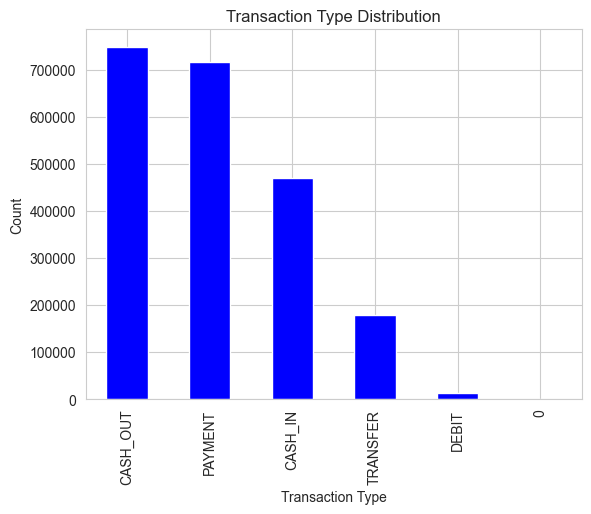

In [138]:
df['type'].value_counts().plot(kind='bar', title='Transaction Type Distribution', color = 'blue')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

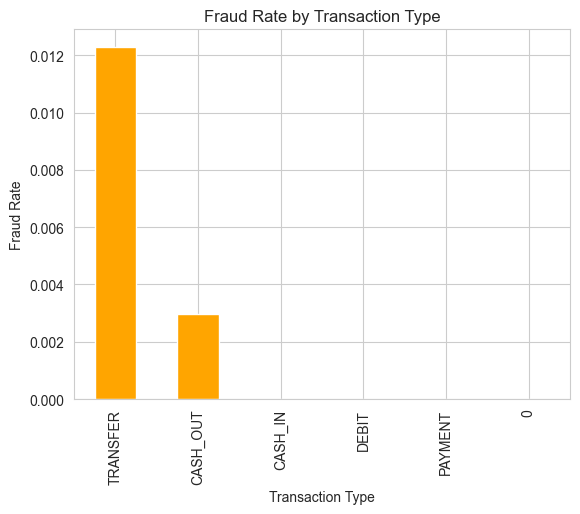

In [139]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title='Fraud Rate by Transaction Type', color = 'orange')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

In [140]:
df['amount'].describe().astype(int)

count     2129193
mean       158109
std        304163
min             0
25%         12060
50%         75047
75%        208359
max      15415938
Name: amount, dtype: int64

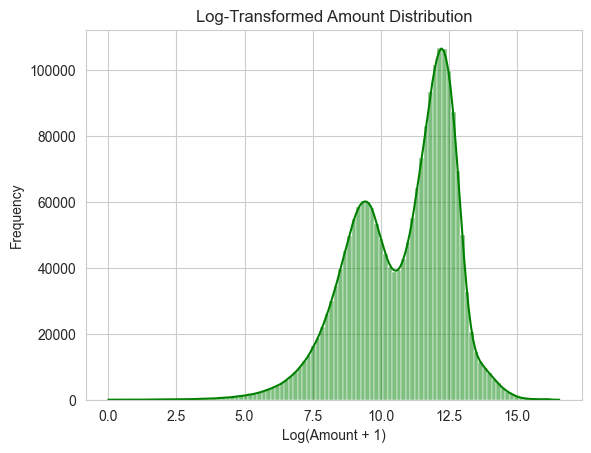

In [141]:
sns.histplot(np.log1p(df['amount']), bins=100, kde=True, color='green')
plt.title('Log-Transformed Amount Distribution')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')
plt.show()

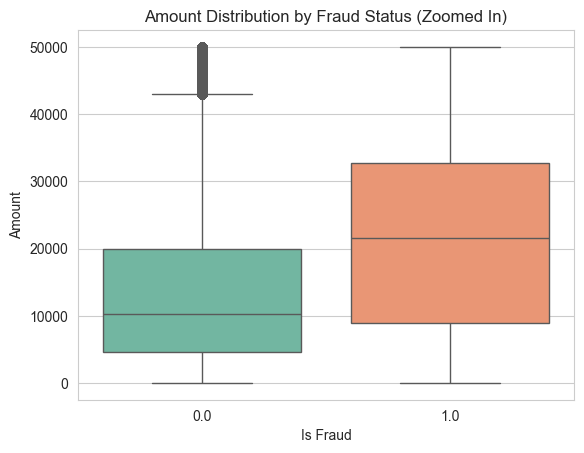

In [142]:
sns.boxplot(x='isFraud', y='amount', data=df[df['amount'] < 50000], palette='Set2')
plt.title('Amount Distribution by Fraud Status (Zoomed In)')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.show()

In [143]:
df['balanceDiff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['oldbalanceDest'] - df['newbalanceDest']

In [144]:
(df['balanceDiff'] < 0).sum()

np.int64(470617)

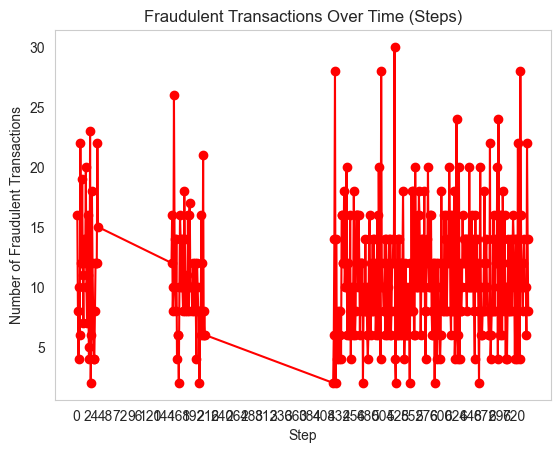

In [145]:
fraud_by_steps = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(fraud_by_steps.index, fraud_by_steps.values, marker='o', color='red')
plt.title('Fraudulent Transactions Over Time (Steps)')
plt.xlabel('Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(0, 744, 24))
plt.grid()
plt.show()

In [146]:
df.drop(columns='step', inplace=True)

In [147]:
top_senders = df['nameOrig'].value_counts().head(10)

In [148]:
top_receivers = df['nameDest'].value_counts().head(10)

In [149]:
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)

In [150]:
fraud_types = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])]

In [151]:
fraud_types['type'].value_counts()

type
CASH_OUT    748752
TRANSFER    179823
Name: count, dtype: int64

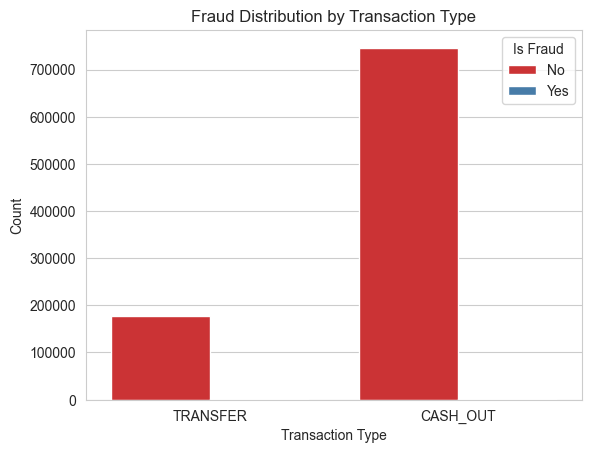

In [152]:
sns.countplot(x='type', hue='isFraud', data=fraud_types, palette='Set1')
plt.title('Fraud Distribution by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(title='Is Fraud', labels=['No', 'Yes'])
plt.show()

In [153]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiff', 'balanceDiffDest', 'isFraud']].corr()

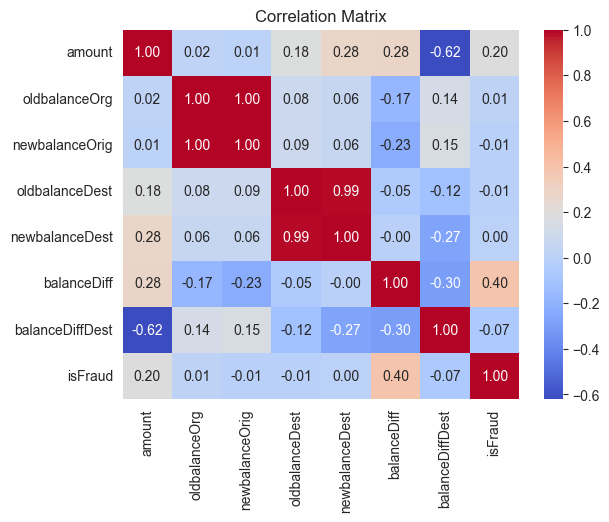

In [154]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [155]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] == 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]

In [156]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [157]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [158]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [159]:
df_model = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [160]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiff,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [162]:
categorical_features = ['type']
numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Drop rows with NaN values in the target variable
df_model = df_model.dropna(subset=['isFraud'])

y = df_model['isFraud']
X = df_model.drop(columns=['isFraud'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [163]:
prepprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ], remainder='drop'
)

In [164]:
pipeline = Pipeline([
    ('prep', prepprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=100))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf', LogisticRegression(class_weight='balanced'))])

In [165]:
y_pred=pipeline.predict(X_test)

In [166]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97    637428
         1.0       0.03      0.92      0.06      1330

    accuracy                           0.94    638758
   macro avg       0.52      0.93      0.52    638758
weighted avg       1.00      0.94      0.97    638758



In [167]:
confusion_matrix(y_test, y_pred)

array([[599721,  37707],
       [   106,   1224]])

In [168]:
pipeline.score(X_test, y_test)

0.9408023069769772

In [169]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [170]:
import joblib
joblib.dump(pipeline, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']